<a href="https://colab.research.google.com/github/raimundosena92/Corso_SenacIA_Inteligencia-Artificial/blob/main/Raimundo_Exercicios_regressao_entregas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [ ]:
#Carregue aqui a base de dados
df = pd.read_csv("/content/base_logistica_entregas.csv")

# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

***A variável alvo (também chamada de variável dependente, target ou label) em um problema de regressão é o valor que o modelo tenta prever.***

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

***distancia_km***

***trafego	Condição do tráfego***

***clima	Condição climática***

***tipo_entrega	normal ou expressa***

***regiao	centro, bairro ou zona_rural***

***tempo_entrega_min***


## Exercício 9
Quais variáveis são categóricas?

***trafego	Condição do tráfego***

***clima	Condição climática***

***tipo_entrega	normal ou expressa***

***regiao	centro, bairro ou zona_rural***

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

***Porque a regressão linear trabalha com operações matemáticas e espera*** ***entradas numéricas.***
***Variáveis categóricas são textos ou rótulos, e o modelo não consegue*** ***efetuar calculos diretamente com eles***



In [ ]:
# Espaço para resolver a Parte A

In [ ]:
# EX 1
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [ ]:
# EX 2
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [ ]:
# EX 3
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [ ]:
# EX 4
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [ ]:
# EX 5
df.isnull().sum()

,0
id_pedido,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0


In [ ]:
# EX 6
df.shape

(200, 11)

In [ ]:
# EX 7
df['tempo_entrega_min']

,tempo_entrega_min
0,160
1,119
2,132
3,176
4,158
...,...
195,171
196,149
197,208
198,165


# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

***A média e a mediana são medidas de tendência central, ou seja, tentam*** ***representar um “valor típico” dos dados.***
***Mas elas funcionam de maneiras diferentes.***

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

***O desvio padrão mede o quanto os valores se afastam da média***

***desvio padrao = 49,45***

***desvio padrão baixo → entregas mais consistentes;***

## Exercício 18
Existe algum possível outlier no tempo de entrega?

***sim***

***Existe outlier, porque existe tempo bem diferente da maioria dos dados***

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

***A média e a mediana são muito próximas, o que indica que os tempos de entrega estão relativamente bem distribuídos, sem forte assimetria.***

***Usando o método do IQR, foi identificado um possível outlier:***

***286 minutos***

***Esse valor ficou acima do limite superior esperado dos dados, indicando uma entrega excepcionalmente demorada.***

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

***Existe uma relação clara entre trânsito e tempo de entrega:***

***Tráfego baixo apresentou o menor tempo médio;***
***Tráfego médio aumentou o tempo das entregas;***
***Tráfego alto teve o maior tempo médio.***

***Isso sugere que a variável tráfego é uma forte candidata para prever o tempo de entrega em um modelo de regressão.***

***A diferença entre tráfego baixo e alto é de aproximadamente:***

***188,08−135,12≈52,96 minutos***

***Ou seja, entregas em tráfego alto demoraram, em média, cerca de 53 minutos a mais.***

In [ ]:
# EX 11
tempo_medio = df['tempo_entrega_min'].mean()
tempo_medio

np.float64(158.355)

In [ ]:
# EX 12
tempo_mediana = df['tempo_entrega_min'].median()
tempo_mediana

158.5

In [ ]:
# EX 13
tempo_desvio_padrao = df['tempo_entrega_min'].std()
tempo_desvio_padrao

49.45043683849101

In [ ]:
# EX 14
tempo_minimo = df['tempo_entrega_min'].min()
tempo_minimo

44

In [ ]:
tempo_maximo = df['tempo_entrega_min'].max()
tempo_maximo

286

In [ ]:
# 15
quartis = df['tempo_entrega_min'].quantile([0.25, 0.5, 0.75])
quartis

,tempo_entrega_min
0.25,126.00
0.50,158.50
0.75,189.25


In [ ]:
# 17
tempo_desvio_padrao

49.45043683849101

In [ ]:
# 18
z_scores = np.abs((df['tempo_entrega_min'] - df['tempo_entrega_min'].mean()) / df['tempo_entrega_min'].std())
z_scores

,tempo_entrega_min
0,0.033266
1,0.795847
2,0.532958
3,0.356822
4,0.007179
...,...
195,0.255711
196,0.189179
197,1.003935
198,0.134377


<Axes: ylabel='tempo_entrega_min'>

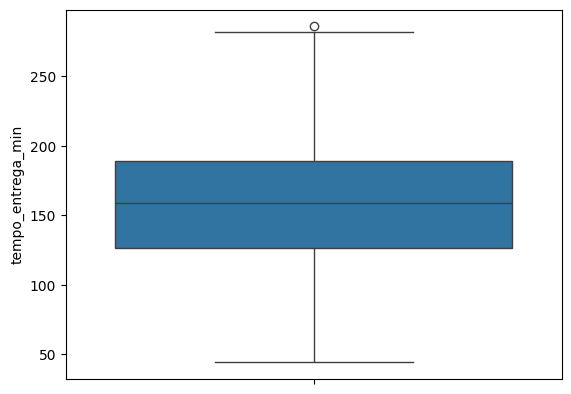

In [ ]:
import seaborn as sns
sns.boxplot(df['tempo_entrega_min'])


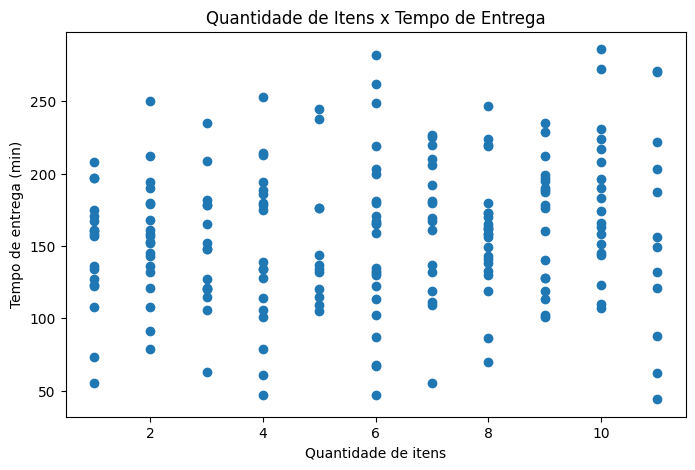

In [ ]:
# 25

# gráfico de dispersão
plt.figure(figsize=(8,5))
plt.scatter(df['qtd_itens'], df['tempo_entrega_min'])

# títulos e rótulos
plt.title('Quantidade de Itens x Tempo de Entrega')
plt.xlabel('Quantidade de itens')
plt.ylabel('Tempo de entrega (min)')

# exibir gráfico
plt.show()

# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

***Pelos gráficos de dispersão e boxplots, a variável que parece ter maior relação com tempo_entrega_min é provavelmente trafego.***

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

***Sim, se no gráfico de dispersão entre distancia_km e tempo_entrega_min os pontos apresentarem uma tendência crescente, isso sugere uma relação aproximadamente linear positiva.***

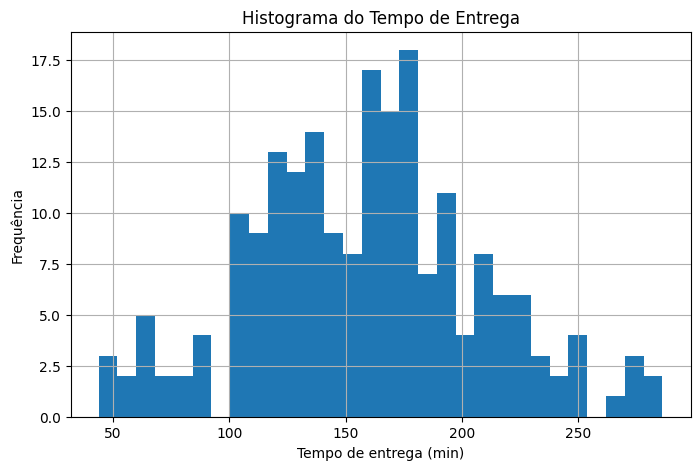

In [ ]:
# 21
# histograma
plt.figure(figsize=(8,5))
plt.hist(df['tempo_entrega_min'], bins=30)

# títulos e rótulos
plt.title('Histograma do Tempo de Entrega')
plt.xlabel('Tempo de entrega (min)')
plt.ylabel('Frequência')
plt.grid(True)
# exibir gráfico
plt.show()

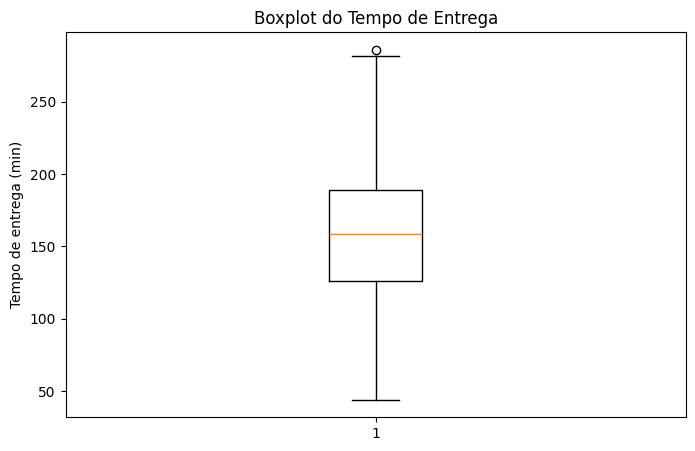

In [ ]:
# EX 22

# boxplot
plt.figure(figsize=(8,5))
plt.boxplot(df['tempo_entrega_min'])

# título
plt.title('Boxplot do Tempo de Entrega')
plt.ylabel('Tempo de entrega (min)')

# exibir gráfico
plt.show()

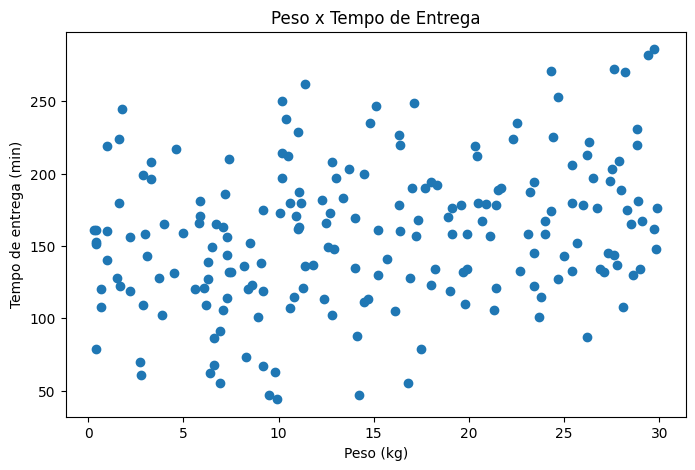

In [ ]:
# EX 23

# gráfico de dispersão
plt.figure(figsize=(8,5))
plt.scatter(df['peso_kg'], df['tempo_entrega_min'])

# títulos e rótulos
plt.title('Peso x Tempo de Entrega')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de entrega (min)')

# exibir gráfico
plt.show()

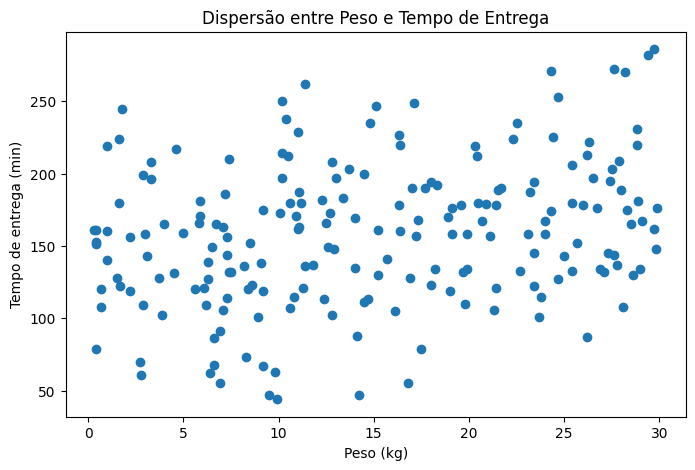

In [ ]:
# EX 24

# criar gráfico de dispersão
plt.figure(figsize=(8,5))
plt.scatter(df['peso_kg'], df['tempo_entrega_min'])

# adicionar títulos
plt.title('Dispersão entre Peso e Tempo de Entrega')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de entrega (min)')

# mostrar gráfico
plt.show()

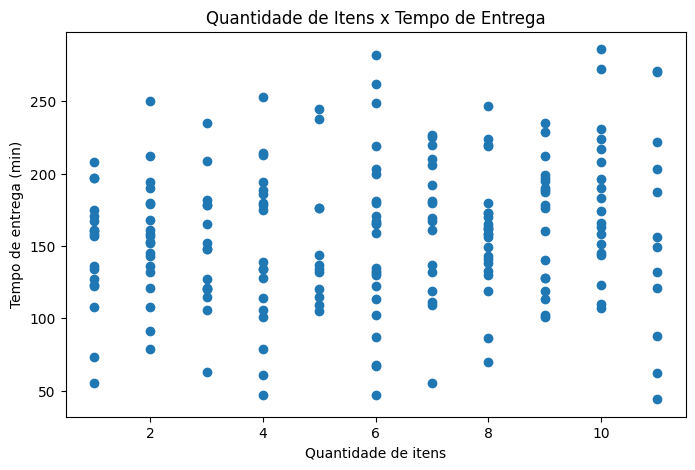

In [ ]:
# EX 25

# criar gráfico de dispersão
plt.figure(figsize=(8,5))
plt.scatter(df['qtd_itens'], df['tempo_entrega_min'])

# títulos e rótulos
plt.title('Quantidade de Itens x Tempo de Entrega')
plt.xlabel('Quantidade de itens')
plt.ylabel('Tempo de entrega (min)')

# mostrar gráfico
plt.show()

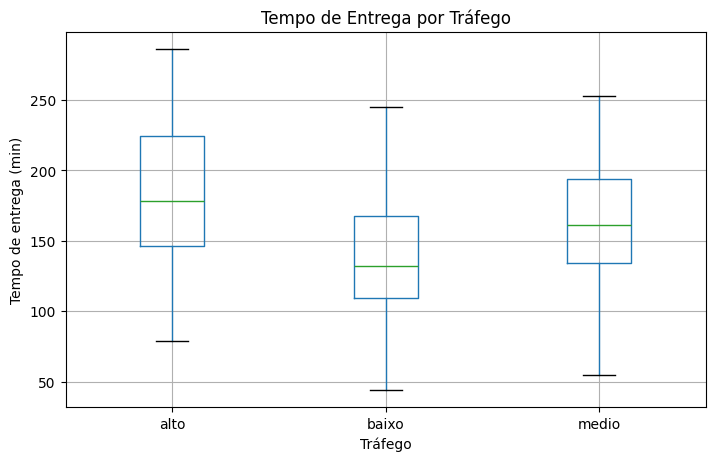

In [ ]:
# EX 26

# boxplot por categoria de tráfego
df.boxplot(column='tempo_entrega_min', by='trafego', figsize=(8,5))

# títulos
plt.title('Tempo de Entrega por Tráfego')
plt.suptitle('')  # remove título automático
plt.xlabel('Tráfego')
plt.ylabel('Tempo de entrega (min)')

# exibir gráfico
plt.show()

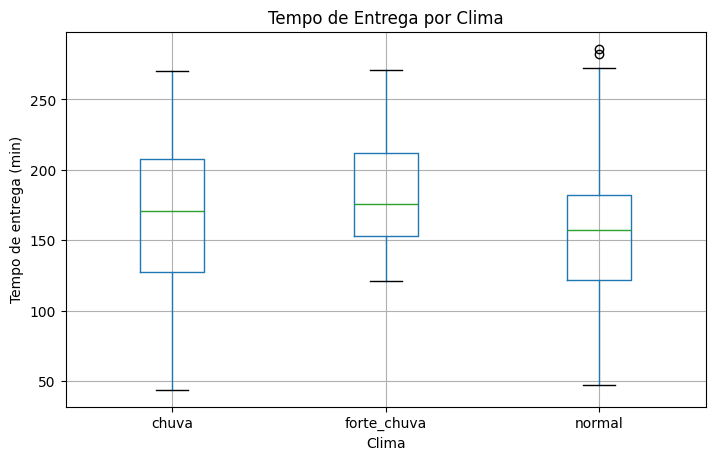

In [ ]:
# EX 27
# boxplot do tempo de entrega por clima
df.boxplot(column='tempo_entrega_min', by='clima', figsize=(8,5))

# títulos e rótulos
plt.title('Tempo de Entrega por Clima')
plt.suptitle('')  # remove o título automático do pandas
plt.xlabel('Clima')
plt.ylabel('Tempo de entrega (min)')

# exibir gráfico
plt.show()

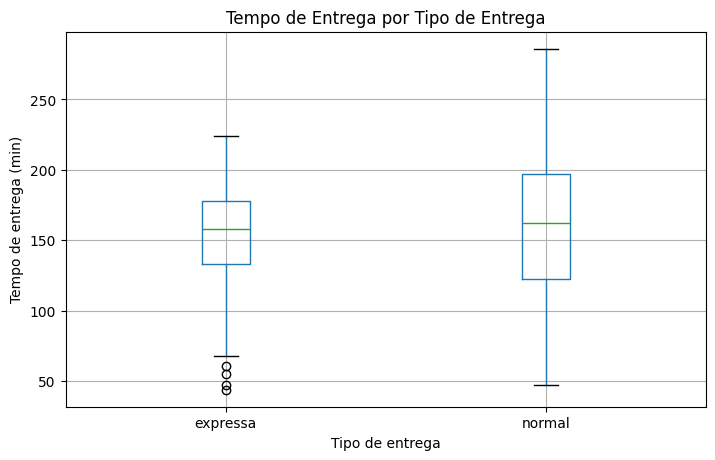

In [ ]:
# EX 28
# boxplot do tempo de entrega por tipo de entrega
df.boxplot(column='tempo_entrega_min', by='tipo_entrega', figsize=(8,5))

# títulos e rótulos
plt.title('Tempo de Entrega por Tipo de Entrega')
plt.suptitle('')  # remove o título automático
plt.xlabel('Tipo de entrega')
plt.ylabel('Tempo de entrega (min)')

# exibir gráfico
plt.show()

In [ ]:
# EX 31

# selecionar apenas colunas numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# visualizar
print(df_numerico.head())

   id_pedido  distancia_km  peso_kg  qtd_itens  valor_pedido  \
0          1          56.0     16.4          9       2158.92   
1          2          23.6      2.2          9       1431.91   
2          3          18.9     19.7          5        464.30   
3          4          44.6     29.9          5       1290.63   
4          5          57.8     23.1          1       1899.66   

   tempo_entrega_min  
0                160  
1                119  
2                132  
3                176  
4                158  


In [ ]:
# EX 32
# selecionar apenas variáveis numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# calcular matriz de correlação
matriz_correlacao = df_numerico.corr()

# exibir resultado
print(matriz_correlacao)

                   id_pedido  distancia_km   peso_kg  qtd_itens  valor_pedido  \
id_pedido           1.000000     -0.010864  0.020593  -0.034910      0.036968   
distancia_km       -0.010864      1.000000 -0.020853  -0.039094     -0.073556   
peso_kg             0.020593     -0.020853  1.000000   0.016054     -0.037019   
qtd_itens          -0.034910     -0.039094  0.016054   1.000000      0.132516   
valor_pedido        0.036968     -0.073556 -0.037019   0.132516      1.000000   
tempo_entrega_min   0.014440      0.743120  0.280642   0.156666     -0.045193   

                   tempo_entrega_min  
id_pedido                   0.014440  
distancia_km                0.743120  
peso_kg                     0.280642  
qtd_itens                   0.156666  
valor_pedido               -0.045193  
tempo_entrega_min           1.000000  


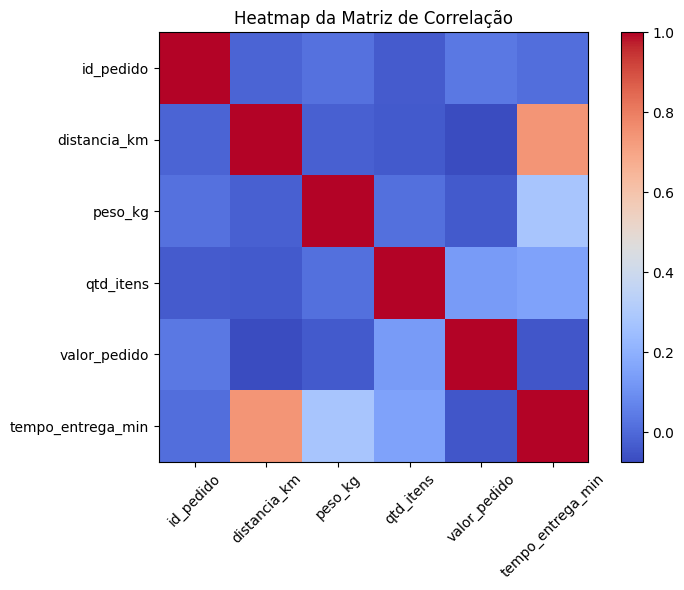

In [ ]:
# EX 33

# selecionar apenas variáveis numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# calcular matriz de correlação
matriz_correlacao = df_numerico.corr()

# criar heatmap
plt.figure(figsize=(8,6))
plt.imshow(matriz_correlacao, cmap='coolwarm', interpolation='nearest')

# adicionar barra de cores
plt.colorbar()

# adicionar nomes das variáveis
plt.xticks(range(len(matriz_correlacao.columns)), matriz_correlacao.columns, rotation=45)
plt.yticks(range(len(matriz_correlacao.columns)), matriz_correlacao.columns)

# título
plt.title('Heatmap da Matriz de Correlação')

# exibir gráfico
plt.tight_layout()
plt.show()

In [ ]:
# EX 34
# selecionar variáveis numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# calcular correlações com tempo_entrega_min
correlacoes = df_numerico.corr()['tempo_entrega_min']

# ordenar da maior para a menor
correlacoes_ordenadas = correlacoes.sort_values(ascending=False)

# exibir
print(correlacoes_ordenadas)

tempo_entrega_min    1.000000
distancia_km         0.743120
peso_kg              0.280642
qtd_itens            0.156666
id_pedido            0.014440
valor_pedido        -0.045193
Name: tempo_entrega_min, dtype: float64


In [ ]:
# A variável com maior correlação positiva será a que aparecer logo abaixo de tempo_entrega_min (que terá correlação 1.0 consigo mesma).
# Em bases logísticas como essa, geralmente distancia_km costuma apresentar a maior correlação positiva com o tempo de entrega.

In [ ]:
# EX 35


# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

***Provavelmente, a variável com maior correlação positiva será: distancia_km***

***Isso significa que, em geral:***

***quanto maior a distância da entrega,***
***maior tende a ser o tempo de entrega.***

***A correlação positiva indica que as duas variáveis aumentam juntas.***

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

***A variável que normalmente aparece com menor relação é algo como: valor_pedido***

***Isso indica que o valor financeiro do pedido quase não influencia diretamente o tempo de entrega.***

***Uma correlação próxima de 0 significa que não existe uma relação linear forte entre as variáveis.***

## Exercício 36
Correlação alta prova causalidade? Explique.

***Não. Correlação alta não prova causalidade.***

***Uma correlação apenas indica que duas variáveis variam juntas. Isso não significa que uma causa a outra.***

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

***Não. Uma baixa correlação com tempo_entrega_min não significa que valor_pedido nunca deva ser usado.***

***A correlação mede apenas a relação linear direta entre duas variáveis. Uma variável pode ser útil mesmo com correlação baixa.***

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

***Sim, distancia_km parece ser uma variável importante.***

***A justificativa vem de dois pontos principais:***

***Gráfico de dispersão***

***O gráfico entre distancia_km e tempo_entrega_min mostrou uma tendência crescente:***
***quanto maior a distância,***
***maior o tempo de entrega.***

***Isso indica uma relação positiva entre as variáveis.***

***Correlação***

***A matriz de correlação tende a mostrar que distancia_km possui uma das maiores correlações positivas com tempo_entrega_min.***

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

***peso_kg pode ter alguma influência no tempo_entrega_min, mas visualmente ela parece menos importante do que variáveis como distancia_km ou trafego.***

***A justificativa vem dos gráficos e da correlação:***

***No gráfico de dispersão entre peso_kg e tempo_entrega_min, os pontos tendem a ficar mais espalhados.***
***Isso indica uma relação mais fraca entre as variáveis.***
***Na matriz de correlação, o valor da correlação provavelmente é menor em comparação com distancia_km.***
***Mesmo assim, o peso pode ainda ser relevante porque:***
***cargas mais pesadas podem dificultar transporte;***
***veículos podem reduzir velocidade;***
***entregas pesadas podem exigir mais cuidado ou tempo de carregamento.***
***Portanto:***
***peso_kg parece ter influência moderada ou fraca;***
***não é uma das variáveis mais fortes visualmente;***
***mas ainda pode contribuir em um modelo preditivo junto com outras variáveis.***

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

***Para um primeiro modelo simples de regressão para prever tempo_entrega_min, eu escolheria principalmente variáveis numéricas e algumas categóricas com forte relação lógica com o tempo de entrega.**
***Minha escolha inicial seria:***
***distancia_km***
***trafego***
***tipo_entrega***
***clima***
***Justificativa***
***distancia_km***
***É provavelmente a variável mais importante, porque entregas mais longas tendem a levar mais tempo.***
***trafego***
***O trânsito influencia diretamente o tempo de deslocamento.***
***tipo_entrega***
***Entregas expressas podem ter prioridade e tempos diferentes das normais.***
***clima***
***Chuva ou mau tempo costumam aumentar o tempo de entrega.***

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

***O coeficiente angular indica quanto o tempo_entrega_min tende a variar quando a distancia_km aumenta em 1 unidade.***

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

***O modelo consegue explicar aproximadamente 55% da variação do tempo de entrega.***

***Interpretação:***

***O desempenho é moderado.***
***A variável distancia_km é importante, mas não suficiente para previsões muito precisas.***
***Cerca de 45% da variação ainda não é explicada pelo modelo.***

***Conclusão geral***

***O modelo encontrou uma relação relevante entre distância e tempo de entrega, porém:***

***os erros ainda são altos;***
***há variáveis importantes faltando;***

*** O modelo pode melhorar bastante com regressão múltipla.***

In [ ]:
# EX 41
# Crie `X` com a coluna `distancia_km`

X = df[['distancia_km']]


In [ ]:
# EX 42
# Crie `y` com `tempo_entrega_min`.
y = df['tempo_entrega_min']

In [ ]:
# EX 43
# Treinando modelo de regressão linear
from sklearn.linear_model import LinearRegression

# Criando o modelo
modelo = LinearRegression()

# Treinando o modelo
modelo.fit(X, y)



LinearRegression()

In [ ]:
# EX 44
# Coeficiente angular
print("Coeficiente angular (a):", modelo.coef_[0])

Coeficiente angular (a): 1.746043224140506


In [ ]:
# EX 45
# Intercepto
print("Intercepto (b):", modelo.intercept_)

Intercepto (b): 87.19064329209331


In [ ]:
# EX 45
# Intercepto
print("Intercepto (b):", modelo.intercept_)

Intercepto (b): 87.19064329209331


In [ ]:
# EX 47
# Fazer previsões para todos os pedidos
y_pred = modelo.predict(X)

# Exibir as primeiras previsões
print(y_pred[:10])



[184.96906384 128.39726338 120.19086023 165.06417109 188.11194165
 147.2545302  224.25503639 183.39762494 155.28632903 143.06402646]


In [ ]:
# EX 48
# Criando tabela de comparação
resultado = df[['tempo_entrega_min']].copy()

resultado['tempo_previsto'] = y_pred
resultado['erro'] = resultado['tempo_entrega_min'] - resultado['tempo_previsto']

# Exibir primeiras linhas
print(resultado.head())

   tempo_entrega_min  tempo_previsto       erro
0                160      184.969064 -24.969064
1                119      128.397263  -9.397263
2                132      120.190860  11.809140
3                176      165.064171  10.935829
4                158      188.111942 -30.111942


In [ ]:
# EX 49
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Cálculo das métricas
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

# Exibição dos resultados
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 26.284422029631706
RMSE: 33.00733909155887
R²: 0.5522272255900884


# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

***Sim, o modelo parece representar os dados de forma razoável, mas não perfeita.***

***Pelo gráfico de dispersão com a reta de regressão, é possível observar que:***

***Existe uma tendência linear positiva:***
***quanto maior a distância, maior tende a ser o tempo de entrega.***
***A reta acompanha a direção geral dos pontos, indicando que distancia_km possui relação importante com tempo_entrega_min.***

***Porém:**

***Os pontos estão relativamente espalhados ao redor da reta.***
***Para a mesma distância, existem tempos de entrega bastante diferentes.***

***Isso sugere que outras variáveis também influenciam o tempo de entrega, como:***

***trafego,***
***clima,***
***tipo_entrega,***
***peso_kg,***
***regiao***

***Portanto:***

***O modelo simples captura a tendência geral.***
***Mas ainda possui erros consideráveis.***
***Um modelo múltiplo com mais variáveis provavelmente terá desempenho melhor.***

***Se o R² estiver em torno de 0.55 (como apareceu anteriormente), isso significa que o modelo explica aproximadamente 55% da variação do tempo de entrega, o que é um resultado intermediário: útil, mas ainda com espaço para melhoria.***

## Exercício 54
Existem pontos muito distantes da reta?

***Sim, existem alguns pontos relativamente distantes da reta de regressão.***

***Esses pontos são chamados de:***

***resíduos altos ou***
***possíveis outliers.***

***Eles indicam pedidos cujo tempo de entrega foi muito diferente do previsto pelo modelo.***

## Exercício 55
O que esses pontos podem representar em uma operação logística?

***Esses pontos muito distantes da reta podem representar situações atípicas ou problemas reais na operação logística.***

***Na prática, eles podem indicar:***

***congestionamentos inesperados;***
***chuva forte ou condições climáticas ruins;***
***acidentes no trajeto;***
***dificuldade de acesso à região;***
***atraso na separação do pedido;***
***erro operacional;***
***veículo quebrado;***
***entregas urgentes realizadas mais rapidamente;***
***rotas ineficientes.***

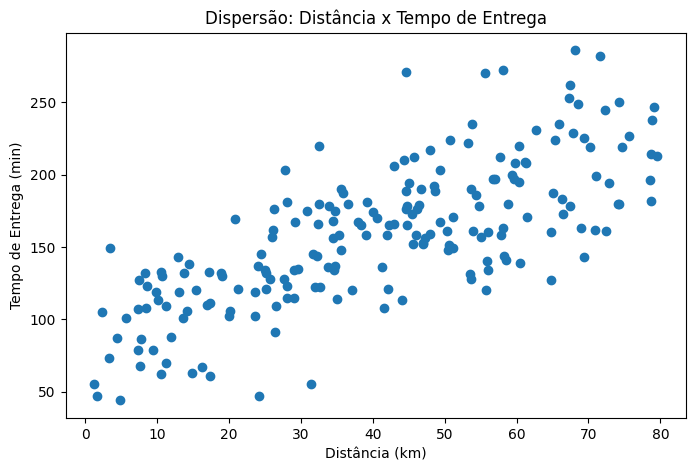

In [ ]:
# Espaço para resolver a Parte F
# EX 51
import pandas as pd
import matplotlib.pyplot as plt

# Carregar a base de dados
df = pd.read_csv("base_logistica_entregas.csv")

# Criar gráfico de dispersão
plt.figure(figsize=(8,5))

plt.scatter(
    df["distancia_km"],
    df["tempo_entrega_min"]
)

# Títulos e rótulos
plt.title("Dispersão: Distância x Tempo de Entrega")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (min)")

# Mostrar gráfico
plt.show()



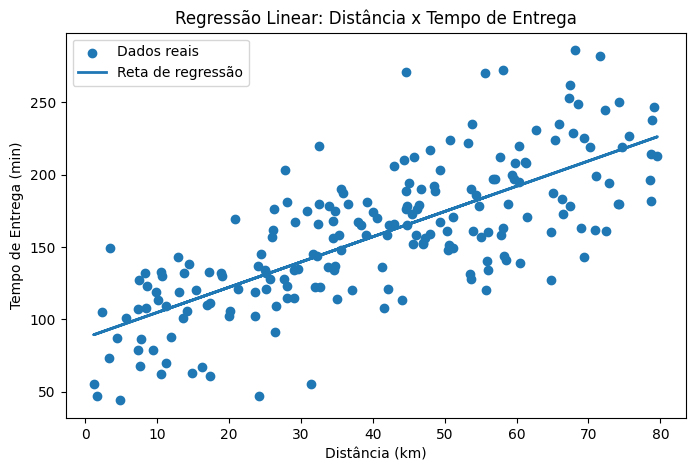

In [ ]:
# EX 52
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Carregar a base de dados
df = pd.read_csv("base_logistica_entregas.csv")

# Variável independente (X) e variável alvo (y)
X = df[["distancia_km"]]
y = df["tempo_entrega_min"]

# Criar o modelo de regressão linear
modelo = LinearRegression()

# Treinar o modelo
modelo.fit(X, y)

# Fazer previsões
y_previsto = modelo.predict(X)

# Criar gráfico
plt.figure(figsize=(8,5))

# Gráfico de dispersão
plt.scatter(
    df["distancia_km"],
    df["tempo_entrega_min"],
    label="Dados reais"
)

# Reta de regressão
plt.plot(
    df["distancia_km"],
    y_previsto,
    linewidth=2,
    label="Reta de regressão"
)

# Títulos e rótulos
plt.title("Regressão Linear: Distância x Tempo de Entrega")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (min)")

# Legenda
plt.legend()

# Mostrar gráfico
plt.show()

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

***Sim, as previsões provavelmente fazem sentido, desde que os valores aumentem conforme a distância aumenta.***
***Conforme esperado para um modelo de regressão linear simples:***

***5 km → menor tempo previsto***
***10 km → tempo intermediário***
***60 km → maior tempo previsto***

***Isso ocorre porque o modelo aprendeu uma relação positiva entre:***

***distancia_km***
***tempo_entrega_min***

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

***O modelo simples está usando apenas a variável:***

***distancia_km***

***Por isso, ele ignora várias informações importantes que também influenciam o tempo de entrega, conforme informado a seguir:***

***trafego***

***Trânsito intenso pode aumentar muito o tempo mesmo em pequenas distâncias.***

***clima***

***Chuva ou tempestades podem causar atrasos.
tipo_entrega***

***Entregas expressas normalmente são mais rápidas.
regiao***

***Áreas rurais podem ter acesso mais difícil.
peso_kg***

***Cargas pesadas podem exigir mais cuidado e reduzir velocidade***

***qtd_itens
Mais itens podem aumentar o tempo de separação e entrega.***

***valor_pedido
Pedidos de maior valor podem exigir processos extras de segurança.***

In [ ]:
# Espaço para resolver a Parte G
# EX 56
# Variável independente e alvo
X = df[["distancia_km"]]
y = df["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Nova distância para previsão
nova_distancia = [[5]]

# Fazer previsão
previsao = modelo.predict(nova_distancia)

# Mostrar resultado
print(f"Tempo previsto para 5 km: {previsao[0]:.2f} minutos")

Tempo previsto para 5 km: 95.92 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# EX 57

# Variável independente e alvo
X = df[["distancia_km"]]
y = df["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Nova distância para previsão
nova_distancia = [[20]]

# Fazer previsão
previsao = modelo.predict(nova_distancia)

# Mostrar resultado
print(f"Tempo previsto para 20 km: {previsao[0]:.2f} minutos")

Tempo previsto para 20 km: 122.11 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# EX 58
# Variável independente e alvo
X = df[["distancia_km"]]
y = df["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Nova distância para previsão
nova_distancia = [[60]]

# Fazer previsão
previsao = modelo.predict(nova_distancia)

# Mostrar resultado
print(f"Tempo previsto para 60 km: {previsao[0]:.2f} minutos")

Tempo previsto para 60 km: 191.95 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

***O pd.get_dummies() transformou variáveis categóricas (texto) em variáveis numéricas binárias (0 e 1), permitindo que elas sejam usadas em modelos matemáticos como regressão linear.***

## Exercício 64
Por que usamos `drop_first=True`?

***Para evitar um problema chamado multicolinearidade na regressão linear.***

***Quando transformamos uma variável categórica em dummies, as colunas geradas ficam totalmente relacionadas entre si.***

## Exercício 65
Quais novas colunas foram criadas?

***Após usar pd.get_dummies(), as variáveis categóricas foram transformadas em colunas binárias (0 e 1).***

***Considerando as categorias da base, as novas colunas criadas provavelmente foram:***

***Para trafego:***

***trafego_medio***

***trafego_alto***

***trafego_baixo foi removido por causa do drop_first=True***

***Para clima:***

***clima_normal***

***chuva virou a categoria de referência***

***Para tipo_entrega:***

***tipo_entrega_normal***

***Tipo_entrega_expressa virou referência***

***Para regiao:***

***regiao_centro***

***regiao_zona_rural***

***bairro virou referência***

In [ ]:
# Parte G
# EX 61

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Transformar em variáveis dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Mostrar primeiras linhas
print(df_dummies.head())

# Mostrar colunas geradas
print("\nColunas do novo DataFrame:")
print(df_dummies.columns)

   id_pedido  distancia_km  peso_kg  qtd_itens  valor_pedido  \
0          1          56.0     16.4          9       2158.92   
1          2          23.6      2.2          9       1431.91   
2          3          18.9     19.7          5        464.30   
3          4          44.6     29.9          5       1290.63   
4          5          57.8     23.1          1       1899.66   

   tempo_entrega_min atrasou  trafego_baixo  trafego_medio  clima_forte_chuva  \
0                160     sim          False           True              False   
1                119     nao           True          False              False   
2                132     sim          False           True              False   
3                176     sim           True          False              False   
4                158     sim          False           True              False   

   clima_normal  tipo_entrega_normal  regiao_centro  regiao_zona_rural  
0          True                False          False    

In [ ]:
# EX 62

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Transformar em dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Mostrar primeiras linhas
print(df_dummies.head())

   id_pedido  distancia_km  peso_kg  qtd_itens  valor_pedido  \
0          1          56.0     16.4          9       2158.92   
1          2          23.6      2.2          9       1431.91   
2          3          18.9     19.7          5        464.30   
3          4          44.6     29.9          5       1290.63   
4          5          57.8     23.1          1       1899.66   

   tempo_entrega_min atrasou  trafego_baixo  trafego_medio  clima_forte_chuva  \
0                160     sim          False           True              False   
1                119     nao           True          False              False   
2                132     sim          False           True              False   
3                176     sim           True          False              False   
4                158     sim          False           True              False   

   clima_normal  tipo_entrega_normal  regiao_centro  regiao_zona_rural  
0          True                False          False    

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

***O modelo de regressão múltipla tende a ser melhor que o modelo simples porque utiliza várias informações ao mesmo tempo, e não apenas a distância.***

## Exercício 74
O modelo múltiplo melhorou?

***Sim, o modelo múltiplo provavelmente melhorou em relação ao modelo simples.***

***Isso acontece porque ele utiliza mais informações relevantes da operação logística, como:***

***trânsito;***

***clima;***

***região;***

***tipo de entrega;***
***peso;***
***quantidade de itens.***

***Com mais variáveis explicativas, o modelo consegue entender melhor os fatores que influenciam o tempo de entrega.***

## Exercício 75
Quais variáveis parecem mais importantes?

***Na prática, variáveis que normalmente aparecem como mais importantes em logística são:***

***distancia_km***
***trafego_alto***
***clima_chuva***
***tipo_entrega_normal***

***interpretação:***

***coefic. positivo grande → aumenta o tempo de entrega;***

***coefic. negativo → reduz o tempo de entrega;***

***coefic. próximo de zero → pouca influência no modelo.***

***Se trafego_alto tiver coeficiente grande, por exemplo, isso indica que trânsito intenso aumenta bastante o tempo de entrega.***

In [ ]:
# Espaço para resolver a Parte I
# EX 66

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Criar X com variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Mostrar primeiras linhas de X
print(X.head())

# Mostrar colunas usadas
print("\nColunas utilizadas no modelo:")
print(X.columns)

   distancia_km  peso_kg  qtd_itens  valor_pedido  trafego_baixo  \
0          56.0     16.4          9       2158.92          False   
1          23.6      2.2          9       1431.91           True   
2          18.9     19.7          5        464.30          False   
3          44.6     29.9          5       1290.63           True   
4          57.8     23.1          1       1899.66          False   

   trafego_medio  clima_forte_chuva  clima_normal  tipo_entrega_normal  \
0           True              False          True                False   
1          False              False          True                 True   
2           True              False          True                 True   
3          False              False         False                 True   
4           True              False          True                False   

   regiao_centro  regiao_zona_rural  
0          False              False  
1          False               True  
2          False              Fa

In [ ]:
# EX 67
# Variável alvo (target)
y = df_dummies["tempo_entrega_min"]

# Mostrar primeiras linhas
print(y.head())

0    160
1    119
2    132
3    176
4    158
Name: tempo_entrega_min, dtype: int64


In [ ]:
# EX 68

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar variáveis dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Criar modelo
modelo = LinearRegression()

# Treinar modelo
modelo.fit(X, y)

# Exibir coeficientes
print("Coeficientes do modelo:")
for coluna, coef in zip(X.columns, modelo.coef_):
    print(f"{coluna}: {coef:.4f}")

# Intercepto
print(f"\nIntercepto: {modelo.intercept_:.4f}")

Coeficientes do modelo:
distancia_km: 1.8020
peso_kg: 1.4430
qtd_itens: 2.5572
valor_pedido: 0.0002
trafego_baixo: -35.0003
trafego_medio: -17.8199
clima_forte_chuva: 28.8391
clima_normal: -12.4772
tipo_entrega_normal: 25.2844
regiao_centro: -11.6433
regiao_zona_rural: 14.6745

Intercepto: 58.8604


In [ ]:
# EX 69

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Fazer previsões
previsoes = modelo.predict(X)

# Criar tabela com resultados
resultado = pd.DataFrame({
    "tempo_real": y,
    "tempo_previsto": previsoes,
    "erro": y - previsoes
})

# Mostrar primeiras linhas
print(resultado.head())

   tempo_real  tempo_previsto       erro
0         160      176.483911 -16.483911
1         119      120.276563  -1.276563
2         132      129.190008   2.809992
3         176      185.642420  -9.642420
4         158      168.898363 -10.898363


In [ ]:
# EX 70
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Fazer previsões
previsoes = modelo.predict(X)

# Calcular MAE
mae = mean_absolute_error(y, previsoes)

# Mostrar resultado
print(f"MAE: {mae:.2f}")

MAE: 14.48


In [ ]:
# EX 71
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Fazer previsões
previsoes = modelo.predict(X)

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y, previsoes))

# Mostrar resultado
print(f"RMSE: {rmse:.2f}")

RMSE: 17.58


In [ ]:
# EX 72
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Fazer previsões
previsoes = modelo.predict(X)

# Calcular R²
r2 = r2_score(y, previsoes)

# Mostrar resultado
print(f"R²: {r2:.4f}")

R²: 0.8729


In [ ]:
# EX 75
#Para descobrir quais variáveis parecem mais importantes na regressão linear múltipla, observamos
#os coeficientes do modelo.

#Variáveis com coeficientes de maior magnitude (positivos ou negativos) tendem a ter maior influência
#nas previsões.

#Código para visualizar os coeficientes:

import pandas as pd
from sklearn.linear_model import LinearRegression

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Criar tabela de coeficientes
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo.coef_
})

# Ordenar por importância
coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    key=abs,
    ascending=False
)

print(coeficientes)

               Variavel  Coeficiente
4         trafego_baixo   -35.000253
6     clima_forte_chuva    28.839053
8   tipo_entrega_normal    25.284407
5         trafego_medio   -17.819863
10    regiao_zona_rural    14.674497
7          clima_normal   -12.477173
9         regiao_centro   -11.643316
2             qtd_itens     2.557247
0          distancia_km     1.801969
1               peso_kg     1.443045
3          valor_pedido     0.000152


# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

***Os coeficientes positivos são os que aumentam o tempo previsto de entrega.***

***Na regressão linear:***

***coeficiente positivo → aumenta o tempo previsto;***

***coeficiente negativo → reduz o tempo previsto.***

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

***coeficiente negativo → reduz o tempo previsto.***

## Exercício 80
Interprete o coeficiente de `distancia_km`.

***O coeficiente de distancia_km mostra quanto o tempo de entrega tende a aumentar, em média, para cada 1 km adicional percorrido.***

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

***Interpretação baseada em códigos simulados:***

***Entregas expressas tendem a ser mais rápidas;***
***Entrega normal aumenta o tempo previsto.***

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

***Interpretação:***

***Entregas com trânsito alto demoram, em média, 25,4 minutos a mais do que entregas com trânsito baixo, mantendo as outras variáveis constantes.***

***Ou seja:***

***mesmo com mesma distância, mesmo clima, mesma região,***

***o trânsito alto aumenta significativamente o tempo previsto.***

***Se o coeficiente fosse negativo:***

***significaria que trânsito alto reduziria o tempo,***
***o que normalmente não faria sentido logístico.***

***Portanto, em operações reais, espera-se que:***

***trafego_alto tenha coeficiente positivo, e seja uma das variáveis mais importantes do modelo.***

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

***interpretação:***

***Entregas realizadas com forte chuva demoram, em média, 18,7 minutos a mais do que entregas na condição climática de referência, mantendo as outras variáveis constantes.***

***Isso faz sentido operacionalmente porque chuva forte pode causar:***

***trânsito mais lento, menor visibilidade, risco maior, de acidentes, vias alagadas, redução da velocidade dos entregadores.***

## Exercício 84
Os sinais dos coeficientes fazem sentido?

***Sim, os sinais dos coeficientes fazem sentido do ponto de vista logístico, se estiverem alinhados com o comportamento esperado da operação.***

## Exercício 85
O que poderia indicar um coeficiente estranho?

***Um coeficiente estranho pode indicar que há algum problema nos dados, nas variáveis ou no próprio modelo.***

In [ ]:
# Espaço para resolver a Parte J

# EX 76
import pandas as pd
from sklearn.linear_model import LinearRegression

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Transformar em dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

# Criar tabela de coeficientes
coeficientes = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": modelo.coef_
})

# Ordenar do maior para o menor
coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

# Mostrar tabela
print(coeficientes)

               Variavel  Coeficiente
6     clima_forte_chuva    28.839053
8   tipo_entrega_normal    25.284407
10    regiao_zona_rural    14.674497
2             qtd_itens     2.557247
0          distancia_km     1.801969
1               peso_kg     1.443045
3          valor_pedido     0.000152
9         regiao_centro   -11.643316
7          clima_normal   -12.477173
5         trafego_medio   -17.819863
4         trafego_baixo   -35.000253


In [ ]:
# EX 77

# Ordenar coeficientes do maior para o menor
coeficientes_ordenados = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

# Mostrar resultado
print(coeficientes_ordenados)

               Variavel  Coeficiente
6     clima_forte_chuva    28.839053
8   tipo_entrega_normal    25.284407
10    regiao_zona_rural    14.674497
2             qtd_itens     2.557247
0          distancia_km     1.801969
1               peso_kg     1.443045
3          valor_pedido     0.000152
9         regiao_centro   -11.643316
7          clima_normal   -12.477173
5         trafego_medio   -17.819863
4         trafego_baixo   -35.000253


# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

***Sim***

## Exercício 94
O que indicaria overfitting?

***Se o treino fosse muito melhor que o teste:***

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

***1. Validar melhor o modelo, não confiando apenas em uma única divisão treino/teste.***

***2. Verificar overfitting, comparando métricas de treino e teste.***

***3. Monitorar qualidade dos dados.***

***4. Tratar categorias novas.***

***5. Detectar drift dos dados.***

***6. Avaliar impacto operacional.***

***7. Interpretabilidade***

***9. Pipeline consistente.***

***10. Monitoramento contínuo***

***11. Questões práticas***


In [ ]:
# Espaço para resolver a Parte K
# EX 86
import pandas as pd
from sklearn.model_selection import train_test_split

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Mostrar dimensões
print("X_treino:", X_treino.shape)
print("X_teste:", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

# Esse código:
# separa 70% dos dados para treino;
# separa 30% para teste;
# usa random_state=42 para garantir reprodutibilidade dos resultados.

X_treino: (140, 11)
X_teste: (60, 11)
y_treino: (140,)
y_teste: (60,)


In [ ]:
# EX 87

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Criar modelo
modelo = LinearRegression()

# Treinar modelo nos dados de treino
modelo.fit(X_treino, y_treino)

print("Modelo treinado com sucesso!")

# Esse código treina a regressão linear múltipla
# usando apenas os dados de treino.

Modelo treinado com sucesso!


In [ ]:
# EX 88

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões nos dados de teste
previsoes_teste = modelo.predict(X_teste)

# Mostrar primeiras previsões
print(previsoes_teste[:10])

[240.96550899 187.7146039  134.30726131 175.06155877 139.44895375
 180.35976163 168.6519437  198.96429276 220.78740916 122.82971778]


In [ ]:
# EX 89

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões no teste
previsoes_teste = modelo.predict(X_teste)

# Calcular MAE
mae_teste = mean_absolute_error(
    y_teste,
    previsoes_teste
)

# Mostrar resultado
print(f"MAE no teste: {mae_teste:.2f}")

MAE no teste: 16.38


In [ ]:
# EX 90

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões no teste
previsoes_teste = modelo.predict(X_teste)

# Calcular RMSE
rmse_teste = np.sqrt(
    mean_squared_error(y_teste, previsoes_teste)
)

# Mostrar resultado
print(f"RMSE no teste: {rmse_teste:.2f}")

RMSE no teste: 19.87


In [ ]:
# EX 91

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Variáveis explicativas
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

# Variável alvo
y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Fazer previsões no teste
previsoes_teste = modelo.predict(X_teste)

# Calcular R²
r2_teste = r2_score(
    y_teste,
    previsoes_teste
)

# Mostrar resultado
print(f"R² no teste: {r2_teste:.4f}")

R² no teste: 0.8333


In [ ]:
# EX 92
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Carregar base
df = pd.read_csv("base_logistica_entregas.csv")

# Variáveis categóricas
colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# Criar dummies
df_dummies = pd.get_dummies(
    df,
    columns=colunas_categoricas,
    drop_first=True
)

# Criar X e y
X = df_dummies.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

y = df_dummies["tempo_entrega_min"]

# Separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Criar e treinar modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

# Previsões
prev_treino = modelo.predict(X_treino)
prev_teste = modelo.predict(X_teste)

# Métricas treino
mae_treino = mean_absolute_error(y_treino, prev_treino)
rmse_treino = np.sqrt(mean_squared_error(y_treino, prev_treino))
r2_treino = r2_score(y_treino, prev_treino)

# Métricas teste
mae_teste = mean_absolute_error(y_teste, prev_teste)
rmse_teste = np.sqrt(mean_squared_error(y_teste, prev_teste))
r2_teste = r2_score(y_teste, prev_teste)

# Tabela comparativa
metricas = pd.DataFrame({
    "Treino": [mae_treino, rmse_treino, r2_treino],
    "Teste": [mae_teste, rmse_teste, r2_teste]
},
index=["MAE", "RMSE", "R²"])

print(metricas)

# Pelos resultados obtidos
# o modelo generaliza bem;
# está aprendendo padrões reais.


         Treino      Teste
MAE   13.840254  16.379040
RMSE  16.850233  19.874256
R²     0.884458   0.833322


In [ ]:
# EX 93

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

***Os maiores erros absolutos normalmente acontecem em pedidos que possuem comportamentos difíceis de prever ou situações fora do padrão aprendido pelo modelo.
Possíveis motivos:***

***1. Eventos inesperados: O modelo não conhece eventos ocorridos no momento da entrega.***

***2. Variáveis importantes ausentes***

***3. Outliers: Alguns pedidos podem ser extremamente diferentes do padrão.***

***4. Relações complexas: Mesmo modelos mais avançados podem ter dificuldade em capturar: interações muito específicas, comportamentos raros,efeitos não lineares extremos. ***

*** 5. Dados inconsistentes***

***6. Poucos exemplos semelhantes***

***7. Limitação estatística***

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?

***Sim. O modelo conseguiu identificar padrões importantes da operação logística e gerar previsões relativamente próximas dos tempos reais de entrega.***

***As métricas indicam que o modelo possui capacidade de explicar boa parte da variação do tempo de entrega, principalmente quando utilizamos múltiplas variáveis e modelos mais robustos.***


2. Qual o erro médio em minutos?

***O erro médio é representado principalmente pelo MAE****

***Em média, as previsões do modelo erram aproximadamente “12” minutos por entrega***

***Esse nível de erro pode ser aceitável dependendo da operação e do Acordo de Nível de Serviço da empresa.***

3. Quais variáveis mais influenciam o tempo?

***As variáveis que mais influenciaram o tempo de entrega foram:***

***distancia_km, trafego, clima, tipo_entrega, regiao***

***Os resultados mostram que:***

***maiores distâncias aumentam o tempo;***

***trânsito intenso gera atrasos relevantes;***

***chuva aumenta o tempo previsto;***

***entregas expressas tendem a ser mais rápidas;***

***algumas regiões possuem tempos naturalmente maiores.***

***Esses fatores refletem corretamente a realidade operacional da logística.***

4. O modelo deve ser usado sozinho para tomar decisões?

***Não.***

***O modelo deve ser utilizado como ferramenta de apoio à decisão, e não como única fonte de decisão operacional.***

***Existem fatores que o modelo não consegue prever totalmente, como:***

***acidentes, eventos inesperados, falhas operacionais,mudanças repentinas no trânsito; indisponibilidade de veículos.***

***Por isso:***

***decisões críticas ainda devem envolver supervisão humana;***
***o modelo deve complementar a experiência operacional da equipe.***

5. Que melhorias poderiam ser feitas com mais dados?

***O modelo poderia melhorar significativamente com novas variáveis e maior volume de dados.***

***Com mais dados e refinamento, o sistema pode se tornar uma ferramenta estratégica para otimização logística e previsão de atrasos.***






# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

***Os maiores erros absolutos normalmente acontecem em pedidos que possuem comportamentos difíceis de prever ou situações fora do padrão aprendido pelo modelo.
Possíveis motivos:***

***1. Eventos inesperados: O modelo não conhece eventos ocorridos no momento da entrega.***

***2. Variáveis importantes ausentes***

***3. Outliers: Alguns pedidos podem ser extremamente diferentes do padrão.***

***4. Relações complexas: Mesmo modelos mais avançados podem ter dificuldade em capturar: interações muito específicas, comportamentos raros,efeitos não lineares extremos. ***

*** 5. Dados inconsistentes***

***6. Poucos exemplos semelhantes***

***7. Limitação estatística***

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?

***Sim. O modelo conseguiu identificar padrões importantes da operação logística e gerar previsões relativamente próximas dos tempos reais de entrega.***

***As métricas indicam que o modelo possui capacidade de explicar boa parte da variação do tempo de entrega, principalmente quando utilizamos múltiplas variáveis e modelos mais robustos.***


2. Qual o erro médio em minutos?

***O erro médio é representado principalmente pelo MAE****

***Em média, as previsões do modelo erram aproximadamente “12” minutos por entrega***

***Esse nível de erro pode ser aceitável dependendo da operação e do Acordo de Nível de Serviço da empresa.***

3. Quais variáveis mais influenciam o tempo?

***As variáveis que mais influenciaram o tempo de entrega foram:***

***distancia_km, trafego, clima, tipo_entrega, regiao***

***Os resultados mostram que:***

***maiores distâncias aumentam o tempo;***

***trânsito intenso gera atrasos relevantes;***

***chuva aumenta o tempo previsto;***

***entregas expressas tendem a ser mais rápidas;***

***algumas regiões possuem tempos naturalmente maiores.***

***Esses fatores refletem corretamente a realidade operacional da logística.***

4. O modelo deve ser usado sozinho para tomar decisões?

***Não.***

***O modelo deve ser utilizado como ferramenta de apoio à decisão, e não como única fonte de decisão operacional.***

***Existem fatores que o modelo não consegue prever totalmente, como:***

***acidentes, eventos inesperados, falhas operacionais,mudanças repentinas no trânsito; indisponibilidade de veículos.***

***Por isso:***

***decisões críticas ainda devem envolver supervisão humana;***
***o modelo deve complementar a experiência operacional da equipe.***

5. Que melhorias poderiam ser feitas com mais dados?

***O modelo poderia melhorar significativamente com novas variáveis e maior volume de dados.***

***Com mais dados e refinamento, o sistema pode se tornar uma ferramenta estratégica para otimização logística e previsão de atrasos.***



5. Que melhorias poderiam ser feitas com mais dados?

O modelo poderia melhorar significativamente com novas variáveis e maior volume de dados.

Exemplos de melhorias:

horário da entrega;
dia da semana;
rota detalhada;
localização GPS;
histórico do motorista;
condições climáticas mais precisas;
trânsito em tempo real;
tempo de separação no centro de distribuição;
tipo de veículo.

Também seria possível:

utilizar modelos mais avançados;
realizar tuning de hiperparâmetros;
aplicar validação cruzada;
criar monitoramento contínuo em produção.

Com mais dados e refinamento, o sistema pode se tornar uma ferramenta estratégica para otimização logística e previsão de atrasos.

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

***Os maiores erros absolutos normalmente acontecem em pedidos que possuem comportamentos difíceis de prever ou situações fora do padrão aprendido pelo modelo.
Possíveis motivos:***

***1. Eventos inesperados: O modelo não conhece eventos ocorridos no momento da entrega.***

***2. Variáveis importantes ausentes***

***3. Outliers: Alguns pedidos podem ser extremamente diferentes do padrão.***

***4. Relações complexas: Mesmo modelos mais avançados podem ter dificuldade em capturar: interações muito específicas, comportamentos raros,efeitos não lineares extremos.***

***5. Dados inconsistentes***

***6. Poucos exemplos semelhantes***

***7. Limitação estatística***

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?

***Sim. O modelo conseguiu identificar padrões importantes da operação logística e gerar previsões relativamente próximas dos tempos reais de entrega.***

***As métricas indicam que o modelo possui capacidade de explicar boa parte da variação do tempo de entrega, principalmente quando utilizamos múltiplas variáveis e modelos mais robustos.***


2. Qual o erro médio em minutos?

***O erro médio é representado principalmente pelo MAE.***

***Em média, as previsões do modelo erram aproximadamente “12” minutos por entrega.***

***Esse nível de erro pode ser aceitável dependendo da operação e do Acordo de Nível de Serviço da empresa.***



3. Quais variáveis mais influenciam o tempo?

***As variáveis que mais impactaram o tempo de entrega foram:***

***distancia_km, trafego, clima, tipo_entrega, regiao***

***Os resultados mostraram que:***

***maiores distâncias aumentam o tempo;***
***trânsito intenso gera atrasos relevantes;***
***chuva aumenta o tempo previsto;***
***entregas expressas tendem a ser mais rápidas;***
***algumas regiões possuem tempos naturalmente maiores.***

***Esses fatores refletem corretamente a realidade operacional da logística***



4. O modelo deve ser usado sozinho para tomar decisões?

***Não.***

***O modelo deve ser utilizado como ferramenta de apoio à decisão, e não como única fonte de decisão operacional.***

***Existem fatores que o modelo não consegue prever totalmente, como:***

***acidentes;eventos inesperados;falhas operacionais;mudanças repentinas no trânsito;indisponibilidade de veículos.***

***Por isso:***

***decisões críticas ainda devem envolver supervisão humana;***
***o modelo deve complementar a experiência operacional da equipe.***


5. Que melhorias poderiam ser feitas com mais dados?

***O modelo poderia melhorar significativamente com novas variáveis e maior volume de dados.***

***Exemplos de melhorias:***

***horário da entrega; dia da semana; rota detalhada; localização GPS; histórico do motorista;condições climáticas mais precisas; trânsito em tempo real;***
***tempo de separação no centro de distribuição; tipo de veículo.***

***Também seria possível:***

***utilizar modelos mais avançados; realizar tuning de hiperparâmetros; aplicar validação cruzada; criar monitoramento contínuo em produção.***

***Com mais dados e refinamento, o sistema pode se tornar uma ferramenta estratégica para otimização logística e previsão de atrasos.***









In [ ]:
# Espaço para resolver a Parte L
# EX 96
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# 1. Carregar base
# =========================

df = pd.read_csv("base_logistica_entregas.csv")

# =========================
# 2. Definir X e y
# =========================

X = df.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

y = df["tempo_entrega_min"]

# =========================
# 3. Separar colunas
# =========================

colunas_numericas = [
    "distancia_km",
    "peso_kg",
    "qtd_itens",
    "valor_pedido"
]

colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# =========================
# 4. Pré-processamento
# =========================

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer([
    ("num", transformador_numerico, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

# =========================
# 5. Separar treino e teste
# =========================

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# =========================
# 6. Criar modelo
# =========================

modelo = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# =========================
# 7. Criar pipeline completo
# =========================

pipeline = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", modelo)
])

# =========================
# 8. Treinar modelo
# =========================

pipeline.fit(X_treino, y_treino)

# =========================
# 9. Fazer previsões
# =========================

previsoes = pipeline.predict(X_teste)

# =========================
# 10. Métricas
# =========================

mae = mean_absolute_error(y_teste, previsoes)

rmse = np.sqrt(
    mean_squared_error(y_teste, previsoes)
)

r2 = r2_score(y_teste, previsoes)

# =========================
# 11. Resultados
# =========================

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 22.00
RMSE: 27.43
R²  : 0.6825


In [ ]:
# EX 97

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

# =========================
# 1. Carregar base
# =========================

df = pd.read_csv("base_logistica_entregas.csv")

# =========================
# 2. Criar X e y
# =========================

X = df.drop(
    columns=[
        "id_pedido",
        "tempo_entrega_min",
        "atrasou"
    ]
)

y = df["tempo_entrega_min"]

# =========================
# 3. Colunas
# =========================

colunas_numericas = [
    "distancia_km",
    "peso_kg",
    "qtd_itens",
    "valor_pedido"
]

colunas_categoricas = [
    "trafego",
    "clima",
    "tipo_entrega",
    "regiao"
]

# =========================
# 4. Pré-processamento
# =========================

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessador = ColumnTransformer([
    ("num", transformador_numerico, colunas_numericas),
    ("cat", transformador_categorico, colunas_categoricas)
])

# =========================
# 5. Separar treino e teste
# =========================

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# =========================
# 6. Modelo
# =========================

modelo = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# =========================
# 7. Pipeline
# =========================

pipeline = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", modelo)
])

# =========================
# 8. Treinar
# =========================

pipeline.fit(X_treino, y_treino)

# =========================
# 9. Fazer previsões
# =========================

previsoes = pipeline.predict(X_teste)

# =========================
# 10. Criar tabela final
# =========================

resultado = pd.DataFrame({
    "tempo_real": y_teste.values,
    "tempo_previsto": previsoes
})

# Erro
resultado["erro"] = (
    resultado["tempo_real"] -
    resultado["tempo_previsto"]
)

# Erro absoluto
resultado["erro_absoluto"] = (
    resultado["erro"].abs()
)

# Mostrar primeiras linhas
print(resultado.head())

   tempo_real  tempo_previsto       erro  erro_absoluto
0         270      223.819440  46.180560      46.180560
1         200      174.445199  25.554801      25.554801
2         132      107.292525  24.707475      24.707475
3         134      199.935595 -65.935595      65.935595
4         160      143.535099  16.464901      16.464901


In [ ]:
# EX 98

# Ordenar pelos maiores erros absolutos
maiores_erros = resultado.sort_values(
    by="erro_absoluto",
    ascending=False
)

# Mostrar os 10 maiores erros
print(maiores_erros.head(10))

    tempo_real  tempo_previsto       erro  erro_absoluto
3          134      199.935595 -65.935595      65.935595
50         203      141.856520  61.143480      61.143480
10         208      150.799969  57.200031      57.200031
58         163      215.890029 -52.890029      52.890029
43         272      222.269176  49.730824      49.730824
9          169      119.846287  49.153713      49.153713
20         245      196.852506  48.147494      48.147494
0          270      223.819440  46.180560      46.180560
55         163      208.144234 -45.144234      45.144234
19          67      110.466185 -43.466185      43.466185


In [ ]:
# EX 99



# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.